# ESE 101: Programming Module 4

**Name:** Tia Abraham

**Date:** November 12, 2025

## Radiation: Radiative Equilibrium and Radiative-Convective Equilibrium
### Ronak Patel, Polina Khapikova, Jordan Benjamin, Shirui Peng, Tapio Schneider
This notebook is adapted from the [The Climate Laboratory](https://brian-rose.github.io/ClimateLaboratoryBook) by [Brian E. J. Rose](http://www.atmos.albany.edu/facstaff/brose/index.html), University at Albany.
_____

In this module, you will learn how various greenhouse gases influence the vertical profile of temperature by using a radiative equilibrium model. You will also see how a parameterization of convection, known as a radiative-convective equilibrium model, influences the vertical profile of temperature in the atmosphere.

**Some notes:**

To successfully run this notebook you will need to install the following packages:
- climlab `conda install -c conda-forge climlab`
- ffmeg-python `conda install -c anaconda ffmeg-python`

Remember:
- **To run each cell in this notebook by pressing `Ctrl+Enter`**
- **To fill in cells marked `Answer:` and be on the lookout for places where you need to add code**<br>
- **Run the code in the `[conda env: hw1_ese101]` environment we created**


Please reach out to the TAs with any and all questions!
_______

### Setup python environment to run this HW in:

The cells below describe a process to set up a python environment to run the code for this HW in. <br>
The lines can be run in the notebook with the prepended exclamation `!` marks, or in terminal/anaconda terminal without them.

In [1]:
%conda install --yes ipykernel nb_conda_kernels nb_conda

2 channel Terms of Service accepted
Retrieving notices: done
Channels:
 - defaults
Platform: osx-arm64
Solving environment: done

# All requested packages already installed.


Note: you may need to restart the kernel to use updated packages.


In [2]:
%conda install -c conda-forge --yes -n hw1_ese101 ffmpeg-python climlab
%conda update -n base -c conda-forge conda

!jupyter kernelspec list
!python -m nb_conda_kernels list 

2 channel Terms of Service accepted
Channels:
 - conda-forge
 - defaults
Platform: osx-arm64
Solving environment: done


==> WARNING: A newer version of conda exists. <==
    current version: 25.7.0
    latest version: 25.9.1

Please update conda by running

    $ conda update -n base -c conda-forge conda



# All requested packages already installed.


Note: you may need to restart the kernel to use updated packages.
2 channel Terms of Service accepted
Channels:
 - conda-forge
 - defaults
Platform: osx-arm64
Solving environment: done


==> WARNING: A newer version of conda exists. <==
    current version: 25.7.0
    latest version: 25.9.1

Please update conda by running

    $ conda update -n base -c conda-forge conda



# All requested packages already installed.


Note: you may need to restart the kernel to use updated packages.
Available kernels:
  python3    /opt/anaconda3/envs/hw1_ese101/share/jupyter/kernels/python3
[ListKernelSpecs] nb_conda_kernels | enabled, 2 kernels found.


<div class="alert alert-block alert-warning">

#### Refresh jupyter/jupyterlab here after installing everything via previous cells (If this doesn't work try closing and reopening the tab)
#### Then, before continuing on through the Analysis, run the cell below
##### or
####  select  [conda env:hw1_ese101]  in menu via < Kernel | Change Kernel | Python [conda env:hw1_ese101] > </div>

In [3]:
%%javascript
Jupyter.notebook.session.restart({kernel_name: 'conda-env-hw1_ese101'})

<IPython.core.display.Javascript object>

# Analysis of Radiative Equilibrium

Let's begin by looking at the observed annual, global-mean temperature profile using the observations of air temperature from the [NCAR-NCEP Reanalysis](https://psl.noaa.gov/data/gridded/data.ncep.reanalysis.html).

In [4]:
import numpy as np
import matplotlib.pyplot as plt
import xarray as xr
from matplotlib.ticker import ScalarFormatter

In [5]:
ncep_url = "http://www.esrl.noaa.gov/psd/thredds/dodsC/Datasets/ncep.\
reanalysis.derived/"
time_coder = xr.coders.CFDatetimeCoder(use_cftime=True)
ncep_air = xr.open_dataset(ncep_url + "pressure/air.mon.1981-2010.ltm.nc", 
                           decode_times=time_coder)

ncep_air

<xarray.Dataset> Size: 17MB
Dimensions:             (time: 12, nbnds: 2, level: 17, lat: 73, lon: 144)
Coordinates:
  * time                (time) object 96B 0001-01-01 00:00:00 ... 0001-12-01 ...
  * level               (level) float32 68B 1e+03 925.0 850.0 ... 30.0 20.0 10.0
  * lat                 (lat) float32 292B 90.0 87.5 85.0 ... -85.0 -87.5 -90.0
  * lon                 (lon) float32 576B 0.0 2.5 5.0 7.5 ... 352.5 355.0 357.5
Dimensions without coordinates: nbnds
Data variables:
    climatology_bounds  (time, nbnds) object 192B ...
    air                 (time, level, lat, lon) float32 9MB ...
    valid_yr_count      (time, level, lat, lon) float32 9MB ...
Attributes:
    description:                     Data from NCEP initialized reanalysis (4...
    platform:                       Model
    Conventions:                    COARDS
    not_missing_threshold_percent:  minimum 3% values input to have non-missi...
    history:                        Created 2011/07/12 by doMonthLTM\nConvert...
    title:                          monthly ltm air from the NCEP Reanalysis
    dataset_title:                  NCEP-NCAR Reanalysis 1
    References:                     http://www.psl.noaa.gov/data/gridded/data...
    _NCProperties:                  version=2,netcdf=4.6.3,hdf5=1.10.5

Compute the global-mean, annual-mean temperature as a function of height. We will provide you the weighting scheme. Name the variable `T_global`

In [6]:
# This cell may take a few minutes to run
coslat = np.cos(np.deg2rad(ncep_air.lat))
weight = coslat / coslat.mean(dim='lat')
# --- code ---
# Calculate the annual-mean by averaging over the 'time' dimension
T_annual = ncep_air.air.mean(dim='time')

# Calculate the zonal-mean by averaging over the 'lon' dimension
T_zonal = T_annual.mean(dim='lon')

# Calculate the weighted global-mean by applying the latitude weights
# and averaging over the 'lat' dimension.
T_global = (T_zonal * weight).mean(dim='lat')
# --- end code ---

Plot the T_global as a function of each pressure level.

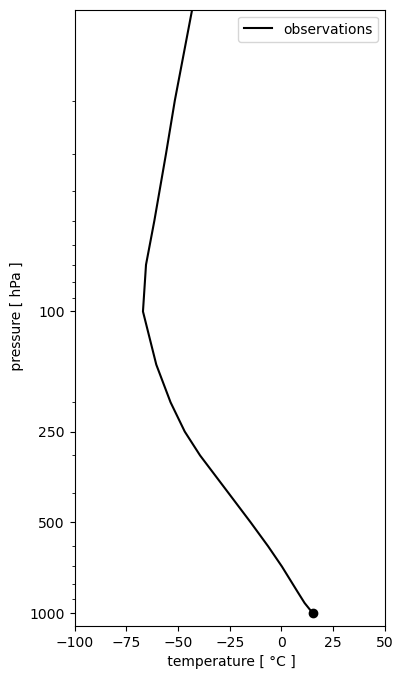

In [7]:
plt.figure(figsize=(4,8))
plt.plot(T_global,T_global.level,c='k',label='observations')
plt.plot(T_global[0],T_global.level[0],'ko')
ax=plt.gca()
ax.invert_yaxis()
ax.set_yscale('log')
ax.set_yticks([100, 250, 500, 1000])
ax.set_ylim(1100,10)
ax.set_xticks(np.arange(-100,75,25))
ax.get_yaxis().set_major_formatter(ScalarFormatter())
plt.ylabel(' pressure [ hPa ]')
plt.xlabel(' temperature [ °C ]')
plt.legend()

Here, we are going to use **Single-Column Models** to understand questions such as:

- What physical factors determine the profile of temperature in the atmosphere? 
- Would the profile be different with different gases in the atmosphere?
- What are the relative roles of **radiation** and **dynamics** in setting this profile?

We will start by **ignoring all processes except radiation**. We will calculate something called the **radiative equilibrium** temperature.

### Radiative equilibrium

Recall our discussion of radiative equilibirum from class. As a reminder, models of radiative transfer slice up the atmospheric air column into a series of layer, and calculate the emission and absorption of radiation within each layer. The concept of radiative equilibrium means that we ignore all methods of heat exchange except for radiation, and ask what temperature profile would exist under that assumption? We can answer this question by using a radiative transfer model to explicity compute the shortwave and longwave beams, and the warming/cooling of each layer associated with the radiative sources and sinks of energy. Basically, we reach radiative equilibrium when energy is received and lost through radiation at the same rate in every layer. Because of the complicated dependence of emission/absorption features on the wavelength of radiation and the different gases, the beam is divided up into many different pieces representing different parts of the electromagnetic spectrum. We will not look explicitly at this complexity here, but we will use a model that represents these processes at the same level of detail we would in a GCM.

Let's begin by setting up a single-column radiation model in **climlab**. We're now going to use **climlab** to run a **complex radiation model**, one that accounts for the spectral absorption properties of different gases.

**climlab** actually provides two different "GCM-level" [radiation codes](https://climlab.readthedocs.io/en/latest/api/climlab.radiation.Radiation.html):

- The [CAM3 radiation module](https://climlab.readthedocs.io/en/latest/api/climlab.radiation.CAM3.html) from NCAR (essentially the same radiation code used in our CESM simulations)
- The [RRTMG (Rapid Radiative Transfer Model)](https://climlab.readthedocs.io/en/latest/api/climlab.radiation.RRTMG.html) which is used in many current climate models

The links above take you to the online [climlab documentation](http://climlab.readthedocs.io/en/latest/intro.html). Developed by Prof. Brian Rose.

We're going to use a model called the [Rapid Radiative Transfer Model](http://rtweb.aer.com/rrtm_frame.html) or RRTMG. This is a "serious" and widely-used radiation model, used in many comprehensive climate models and numerical weather prediction models.

**climlab** provides an easy-to-use Python wrapper for the RRTMG code.

#### Setting up the model

Before setting up the model, we need some water vapor data. Why? Because our model needs to know how much water vapor exists at each vertical level, since water vapor is a radiatively important gas. We're actually going to use the specific humidity field from our CESM control simulation (the same model we have been looking at in the previous problem sets). We'll just take the global, time average of this data, and plot its vertical profile. Here, we are just giving you a global-mean profile of humidity for sake of simplicity.

In [8]:
Q_global = np.array([2.16104904e-06, 2.15879387e-06, 2.15121262e-06, 
                     2.13630949e-06,
       2.12163684e-06, 2.11168002e-06, 2.09396914e-06, 2.10589390e-06,
       2.42166155e-06, 3.12595653e-06, 5.01369691e-06, 9.60746488e-06,
       2.08907654e-05, 4.78823747e-05, 1.05492451e-04, 2.11889055e-04,
       3.94176751e-04, 7.10734458e-04, 1.34192099e-03, 2.05153261e-03,
       3.16844784e-03, 4.96883408e-03, 6.62218037e-03, 8.38350326e-03,
       9.38620899e-03, 9.65030544e-03])

level = np.array([  3.544638,   7.388814,  13.967214,  23.944625,  37.23029 ,  
                  53.114605,
        70.05915 ,  85.439115, 100.514695, 118.250335, 139.115395, 163.66207 ,
       192.539935, 226.513265, 266.481155, 313.501265, 368.81798 , 433.895225,
       510.455255, 600.5242  , 696.79629 , 787.70206 , 867.16076 , 929.648875,
       970.55483 , 992.5561  ])

And make a figure:

Text(0.5, 0, 'specific humidity [ g/kg ]')

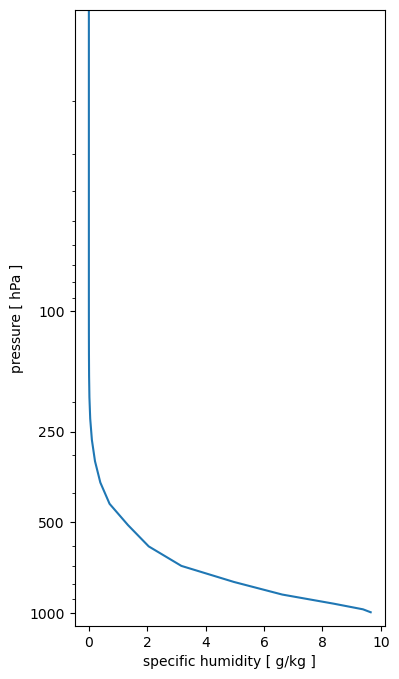

In [9]:
plt.figure(figsize=(4,8))
plt.plot(Q_global*1000, level,c='C0')
ax=plt.gca()
ax.invert_yaxis()
ax.set_yscale('log')
ax.set_yticks([100, 250, 500, 1000])
ax.set_ylim(1100,10)
ax.get_yaxis().set_major_formatter(ScalarFormatter())
ax.set_ylabel('pressure [ hPa ]')
ax.set_xlabel('specific humidity [ g/kg ]')

**This shows a typical climatological humidity profile. Based on this figure, where is most of the water vapor and why? Estimate an e-folding height for the water vapor profile.**

<b> Answer: </b>

<div class="alert alert-block alert-warning">

### Analysis of Water Vapor Profile

* **Location:** Most of the water vapor is concentrated at the **bottom of the atmosphere, near the surface** (around 1000 hPa). The specific humidity is highest at the surface (nearly 10 g/kg) and decreases very rapidly with altitude.
* **Reason:** This distribution is primarily controlled by temperature.
    * The main source of atmospheric water vapor is evaporation from the surface (oceans, lakes, land).
    * The maximum amount of water vapor that air can hold (its saturation vapor pressure) is strongly dependent on temperature: warmer air can hold much more moisture than cold air.
    * Since temperature is highest at the surface and typically decreases with altitude through the troposphere (the lapse rate), the air near the surface can hold the most water vapor. As air rises, it cools, and its capacity to hold water vapor drops exponentially, causing the vapor to condense into clouds. This process confines the vast majority of water vapor to the warm, lowermost part of the atmosphere.

---

### E-folding Height Estimation

The e-folding height is the altitude over which the concentration drops to $1/e$ (or about 37%) of its initial value.

1.  **Surface Value:** The specific humidity at the surface (993 hPa) is approximately **9.7 g/kg**.
2.  **Target Value (1/e):** We need to find the pressure level where the humidity drops to $9.7 / e \approx$ **3.6 g/kg**.
3.  **Find Altitude:** Looking at the graph:
    * The 5 g/kg mark is just below 700 hPa.
    * The 3.6 g/kg value appears to be right around the **700 hPa** pressure level.

The pressure at the e-folding height is roughly 700 hPa. In a standard atmosphere, this corresponds to an altitude of approximately **2.5 to 3 km**. This very short e-folding height confirms just how strongly water vapor is concentrated near the surface.

</div>

#### Create a single-column model on the same grid as this water vapor data:

Here we will create the grid and state variables (air and surface temperature) for our single-column model.

In [10]:
# import the model package
import climlab

#  Make a model on same vertical domain as the GCM
mystate = climlab.column_state(lev=level, water_depth=2.5)
print(mystate)

AttrDict({'Ts': Field([288.]), 'Tatm': Field([200.  , 203.12, 206.24, 209.36, 212.48, 215.6 , 218.72, 221.84,
       224.96, 228.08, 231.2 , 234.32, 237.44, 240.56, 243.68, 246.8 ,
       249.92, 253.04, 256.16, 259.28, 262.4 , 265.52, 268.64, 271.76,
       274.88, 278.  ])})


In [11]:
radmodel = climlab.radiation.RRTMG(
    name='Radiation (all gases)',  # give our model a name!
    state=mystate,   # give our model an initial condition!
    specific_humidity=Q_global,  # tell the model how much water vapor there is
    albedo = 0.25,  # this the SURFACE shortwave albedo
    # set the timestep to one day (measured in seconds)
    timestep = climlab.constants.seconds_per_day)
print(radmodel)

climlab Process of type <class 'climlab.radiation.rrtm.rrtmg.RRTMG'>. 
State variables and domain shapes: 
  Ts: (1,) 
  Tatm: (26,) 
The subprocess tree: 
Radiation (all gases): <class 'climlab.radiation.rrtm.rrtmg.RRTMG'>
   SW: <class 'climlab.radiation.rrtm.rrtmg_sw.RRTMG_SW'>
   LW: <class 'climlab.radiation.rrtm.rrtmg_lw.RRTMG_LW'>



#### Explore the single-column model object

First, let's look at a few interesting properties of the model we just created. Below is the state dictionary we already created, which shows surface temperautre and air temperature.

In [12]:
radmodel.state

AttrDict({'Ts': Field([288.]), 'Tatm': Field([200.  , 203.12, 206.24, 209.36, 212.48, 215.6 , 218.72, 221.84,
       224.96, 228.08, 231.2 , 234.32, 237.44, 240.56, 243.68, 246.8 ,
       249.92, 253.04, 256.16, 259.28, 262.4 , 265.52, 268.64, 271.76,
       274.88, 278.  ])})

We also have our grid for the pressure levels in hPa.

In [13]:
radmodel.lev

array([  3.544638,   7.388814,  13.967214,  23.944625,  37.23029 ,
        53.114605,  70.05915 ,  85.439115, 100.514695, 118.250335,
       139.115395, 163.66207 , 192.539935, 226.513265, 266.481155,
       313.501265, 368.81798 , 433.895225, 510.455255, 600.5242  ,
       696.79629 , 787.70206 , 867.16076 , 929.648875, 970.55483 ,
       992.5561  ])

There is a dictionary called `absorber_vmr` that holds the *volume mixing ratio* of all the radiatively active gases in the column:

In [14]:
radmodel.absorber_vmr

{'CO2': 0.000348,
 'CH4': 1.65e-06,
 'N2O': 3.06e-07,
 'O2': 0.21,
 'CFC11': 0.0,
 'CFC12': 0.0,
 'CFC22': 0.0,
 'CCL4': 0.0,
 'O3': array([7.52507018e-06, 8.51545795e-06, 7.87041289e-06, 5.59601020e-06,
        3.46128454e-06, 2.02820936e-06, 1.13263102e-06, 7.30182697e-07,
        5.27326553e-07, 3.83940962e-07, 2.82227214e-07, 2.12188506e-07,
        1.62569291e-07, 1.17991442e-07, 8.23582543e-08, 6.25738219e-08,
        5.34457156e-08, 4.72688637e-08, 4.23614749e-08, 3.91392482e-08,
        3.56025264e-08, 3.12026770e-08, 2.73165152e-08, 2.47190016e-08,
        2.30518624e-08, 2.22005071e-08])}

Most are just a single number because they are assumed to be **well mixed** in the atmosphere. 

**Why is this an okay assumption for some gases, but not for O$_3$ or H$_2$O?**

<b> Answer: </b>

<div class="alert alert-block alert-warning">

As we established in the last problem set, whether this assumption is okay depends on the gas's **atmospheric lifetime** relative to atmospheric mixing times.

  * **Well-Mixed Gases (like $CO_2$):** This assumption is okay for gases like $CO_2$ because they have **long lifetimes**. Their sources and sinks are very slow compared to atmospheric mixing, allowing winds to stir them evenly. This makes their concentration "approximately constant with latitude and altitude" (Hartmann ch. 3, pg. 78-79).
  * **Not Well-Mixed Gases (like $H_2O$ or $O_3$):** This assumption is **not okay** for $H_2O$ and $O_3$ because they have **short lifetimes** due to fast, localized sources and sinks.
      * **$H_2O$ (Water Vapor)** is "highly variable" (Hartmann ch. 3, pg. 78). Its sources (evaporation) and sinks (condensation) are "fast and depend strongly on temperature," which confines its concentration to specific altitudes and locations (Hartmann ch. 3, p. 78; Petty ch. 12, pg. 384).
      * **$O_3$ (Ozone)** is also variable. It has "fast sources and sinks in the stratosphere" (where it's produced by sunlight) and is also "produced...near the surface" by smog. Because its concentration is locked to these specific altitudes, it cannot be evenly mixed (Hartmann ch. 3, pg. 79).

</div>

Here is how to grab a certain gas. Note, this is $\text{CO}_2$ in parts per million

In [15]:
#  E.g. the CO2 content (a well-mixed gas) in parts per million
radmodel.absorber_vmr['CO2'] * 1E6

348.0

**Plot the vertical profile of ozone, similar to the one we made of specific humidity.**

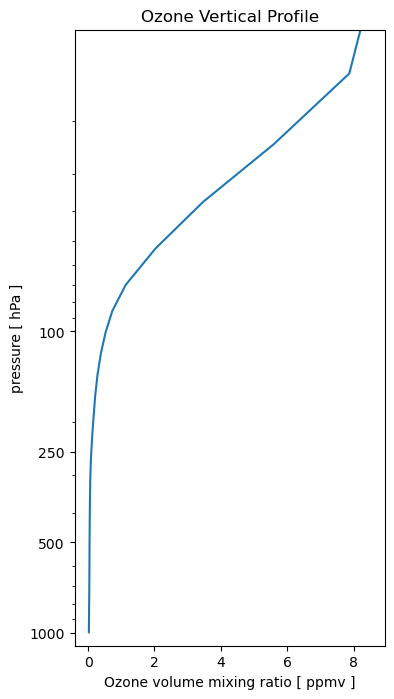

In [16]:
# --- code ---
# Convert O3 VMR to ppmv (parts per million by volume)
O3_ppmv = radmodel.absorber_vmr['O3'] * 1E6

# Make a figure, similar to the Q_global plot
plt.figure(figsize=(4,8))
plt.plot(O3_ppmv, radmodel.lev, c='C0')
plt.title('Ozone Vertical Profile')
plt.ylabel('pressure [ hPa ]')
plt.xlabel('Ozone volume mixing ratio [ ppmv ]')
ax = plt.gca()
ax.invert_yaxis()
ax.set_yscale('log')
ax.set_yticks([100, 250, 500, 1000])
ax.set_ylim(1100, 10)
ax.get_yaxis().set_major_formatter(ScalarFormatter())
# ---

**Where is most of the ozone in the atmosphere? Why is this?**

<b> Answer: </b>

<div class="alert alert-block alert-warning">

**Where is most of the ozone?**
Based on the plot, the ozone concentration is very low near the surface (1000 hPa) and through the troposphere. The volume mixing ratio increases dramatically at low pressures, reaching its maximum **high in the stratosphere** (at pressures well below 100 hPa).

**Why is this?**
This distribution is because, unlike water vapor (which comes from surface evaporation), ozone is **produced at high altitudes**. It has "fast sources and sinks in the stratosphere" where it is most abundant (Hartmann ch. 3, pg. 79). Specifically, it is created by high-energy solar ultraviolet (UV) radiation interacting with oxygen ($O_2$) molecules, a photochemical process that can only happen at these high altitudes where the UV radiation is strong (Hartmann ch. 3, pg. 79).

</div>

#### The RRTMG radiation model has lots of different input parameters

For details you can look at the [documentation](http://climlab.readthedocs.io/en/latest/api/climlab.radiation.radiation.html), but here is a list of each parameter.

In [17]:
for item in radmodel.input:
    print(item)

specific_humidity
absorber_vmr
cldfrac
clwp
ciwp
r_liq
r_ice
emissivity
S0
coszen
irradiance_factor
aldif
aldir
asdif
asdir
icld
irng
idrv
permuteseed_sw
permuteseed_lw
dyofyr
inflgsw
inflglw
iceflgsw
iceflglw
liqflgsw
liqflglw
tauc_sw
tauc_lw
ssac_sw
asmc_sw
fsfc_sw
tauaer_sw
ssaaer_sw
asmaer_sw
ecaer_sw
tauaer_lw
isolvar
indsolvar
bndsolvar
solcycfrac


Many of the parameters control the **radiative effects of clouds**. Here, however, we should note that the model is **initialized with no clouds at all**.

In [18]:
radmodel.cldfrac

0.0

#### Run to radiative equilibrium in the single-column model
Now we are going to run the model to learn about the relative importance of each gas. To do this, we need to step the model forward in time.

Here are the current temperatures (i.e., initial condition):

In [19]:
radmodel.Ts

Field([288.])

In [20]:
radmodel.Tatm

Field([200.  , 203.12, 206.24, 209.36, 212.48, 215.6 , 218.72, 221.84,
       224.96, 228.08, 231.2 , 234.32, 237.44, 240.56, 243.68, 246.8 ,
       249.92, 253.04, 256.16, 259.28, 262.4 , 265.52, 268.64, 271.76,
       274.88, 278.  ])

Now let's take a single timestep:

In [21]:
radmodel.step_forward()

In [22]:
radmodel.Ts

Field([288.57727148])

Note that the surface got warmer. Let's take a look at all the diagnostic information that was generated during that timestep:

### Diagnostic variables in our single-column model

Every climlab model has a `diagnostics` dictionary. Here we are going to check it out as an `xarray` dataset:

In [23]:
climlab.to_xarray(radmodel.diagnostics)

<xarray.Dataset> Size: 4kB
Dimensions:           (depth: 1, lev: 26, lev_bounds: 27, depth_bounds: 2)
Coordinates:
  * depth             (depth) float64 8B 1.25
  * lev               (lev) float64 208B 3.545 7.389 13.97 ... 929.6 970.6 992.6
  * lev_bounds        (lev_bounds) float64 216B 0.0 5.467 10.68 ... 981.6 1e+03
  * depth_bounds      (depth_bounds) float64 16B 0.0 2.5
Data variables: (12/26)
    OLR               (depth) float64 8B 251.0
    OLRclr            (depth) float64 8B 251.0
    OLRcld            (depth) float64 8B 0.0
    TdotLW            (lev) float64 208B -1.505 -0.8463 ... -0.1981 1.523
    TdotLW_clr        (lev) float64 208B -1.505 -0.8463 ... -0.1981 1.523
    LW_sfc            (depth) float64 8B 93.93
    ...                ...
    SW_flux_up        (lev_bounds) float64 216B 86.52 86.35 86.24 ... 54.9 54.59
    SW_flux_down      (lev_bounds) float64 216B 341.3 335.3 ... 220.3 218.4
    SW_flux_net       (lev_bounds) float64 216B 254.8 248.9 ... 165.4 163.8
    SW_flux_up_clr    (lev_bounds) float64 216B 86.52 86.35 86.24 ... 54.9 54.59
    SW_flux_down_clr  (lev_bounds) float64 216B 341.3 335.3 ... 220.3 218.4
    SW_flux_net_clr   (lev_bounds) float64 216B 254.8 248.9 ... 165.4 163.8

The main "job" of a radiative transfer model it to calculate the shortwave and longwave fluxes up and down between each model layer.

For example:

In [24]:
climlab.to_xarray(radmodel.LW_flux_up)

<xarray.DataArray (lev_bounds: 27)> Size: 216B
Field([251.01459805, 251.25313801, 251.62168893, 252.36094038,
       253.49760842, 254.94148495, 256.51042674, 257.95176838,
       259.23376945, 260.55457866, 261.96972717, 263.51365698,
       265.24255886, 267.2270195 , 269.61795334, 272.55968463,
       276.15994067, 280.45320896, 285.55601094, 291.88950856,
       299.3801653 , 308.24370169, 319.18061254, 331.81032106,
       346.00223519, 360.37156583, 390.0990181 ])
Coordinates:
  * lev_bounds  (lev_bounds) float64 216B 0.0 5.467 10.68 ... 950.1 981.6 1e+03

These are upward longwave fluxes in W m$^{-2}$.

The last element of the flux array represents the **upward flux from the surface to the first level**:

In [25]:
radmodel.LW_flux_up[-1]

np.float64(390.0990181032836)

The value is about 390 W $\text{m}^{-2}$. 

**Why? Think about what we learned about outgoing longwave radiation? What does it depend on? Estimate the brightness temperature at the surface from this flux.**

<b> Answer: </b>

<div class="alert alert-block alert-warning">

This value of **390.1 W m⁻²** is the thermal radiation being emitted by the surface.

* **What it depends on:** This upward longwave flux is determined by the **surface temperature** ($T_s$) and the **surface emissivity** ($\epsilon$). The model calculates this using the **Stefan-Boltzmann Law**: $F = \epsilon \sigma T_s^4$ (Hartmann ch. 4, pg. 106). The model assumes the surface is a blackbody ($\epsilon=1$).

* **Why this value:** The model was initialized with a surface temperature `radmodel.Ts` of **288.0 K**. Plugging this into the law gives the exact flux we see:
    $F = 1.0 \times (5.67 \times 10^{-8} \text{ W m}^{-2} \text{K}^{-4}) \times (288.0 \text{ K})^4 \approx$ **390.1 W m⁻²**

---
### Brightness Temperature Estimate

To estimate the brightness temperature from the flux, we just reverse the Stefan-Boltzmann formula:

$T = (F / \sigma)^{1/4}$

$T = (390.099 \text{ W m}^{-2} / 5.67 \times 10^{-8} \text{ W m}^{-2} \text{K}^{-4})^{1/4}$

$T \approx$ **288.0 K**

This confirms that the 390.1 W m⁻² flux is precisely the radiation emitted by a blackbody at the initial surface temperature of 288.0 K.

</div>

What about the flux from the top layer out to space?

There are two ways to access this information:

In [26]:
radmodel.LW_flux_up[0]

np.float64(251.01459805296048)

In [27]:
radmodel.OLR

Field([251.01459805])

Of course there is a whole other set of fluxes for the shortwave radiation.

One diagnostic we will often want to look at is the **net energy budget at the top of the atmosphere**:

In [28]:
radmodel.ASR - radmodel.OLR

Field([3.76767763])

This is the balance between absorved shortwave radiation (ASR) and outgoing longwave radiation (OLR).

**Is the model gaining or losing energy?**

<b> Answer: </b>

<div class="alert alert-block alert-warning">

Based on that diagnostic, the model is **gaining energy**.

The value `3.76767763` is positive, which means the **absorbed shortwave radiation (ASR)** is greater than the **outgoing longwave radiation (OLR)**. More energy is entering the system than leaving it, so the model is warming up.

</div>

#### Let's integrate the model to equilibrium
Here, we want to step forward in time until the model is very close to energy balance.
We can use a `while` loop, conditional on the top-of-atmosphere imbalance:

In [29]:
while np.abs(radmodel.ASR - radmodel.OLR) > 0.01:
    radmodel.step_forward()

Check the energy budget again:

In [30]:
#  Check the energy budget again
radmodel.ASR - radmodel.OLR

Field([0.00988074])

Indeed, the imbalance is now small.

### Compare the radiative equilibrium temperature to observations

In [31]:
radmodel.Ts

Field([314.97571371])

Let's plot the equilibrium profile.

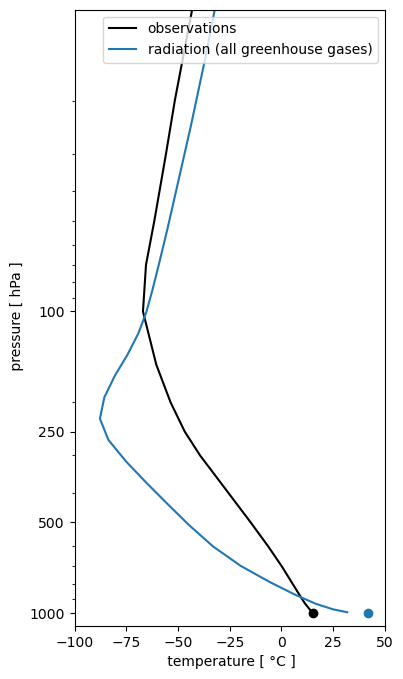

In [32]:
plt.figure(figsize=(4,8))
plt.plot(T_global,T_global.level,c='k',label='observations')
plt.plot(T_global[0],T_global.level[0],'ko')

plt.plot(radmodel.Tatm-273.15,radmodel.lev,c='C0',
         label='radiation (all greenhouse gases)')
plt.plot(radmodel.Ts-273.15,1000,'o')

ax=plt.gca()
ax.invert_yaxis()
ax.set_yscale('log')
ax.set_yticks([100, 250, 500, 1000])
ax.set_ylim(1100,10)
ax.set_xticks(np.arange(-100,75,25))
ax.get_yaxis().set_major_formatter(ScalarFormatter())
plt.ylabel(' pressure [ hPa ]')
plt.xlabel(' temperature [ °C ]')
plt.legend()

**What do you think about this model? How well did we do? Remember this is purely a radiative equilibrium model. Where does the model do well and where does it not do well?**

<b> Answer: </b>

<div class="alert alert-block alert-warning">

### How well did the model do?

Overall, the model does a **poor job** of matching the observed temperature profile, especially in the lower half of the atmosphere (the troposphere). However, it does a surprisingly good job of capturing the physics of the upper atmosphere (the stratosphere).

---

### Where the Model Fails: The Troposphere (Surface to ~150 hPa)

* **Surface Temperature:** The model's equilibrium surface temperature is far too hot. The plot shows the model's surface temperature (blue dot) is around **42°C** (which matches the `314.97 K` value found previously), while the observed temperature (black dot) is only about **15°C**.
* **Temperature Profile (Lapse Rate):** The model's temperature (blue line) drops off much more rapidly with altitude than the observed (black) line. This steep profile is known as the **purely radiative equilibrium (RE) lapse rate**.

**Why it fails here:** This model is missing **convection**. A purely radiative atmosphere is convectively unstable, meaning the hot air at the bottom would naturally rise. In the real world, this vertical mixing (convection) transports heat from the surface up into the atmosphere, which **cools the surface** and **warms the troposphere**. This leads to the more stable, gentler temperature profile (the "radiative-convective equilibrium") that we observe.

---

### Where the Model Succeeds: The Stratosphere (Above ~150 hPa)

* **Temperature Profile:** Above ~150 hPa, the model's blue line gets much closer to the observed black line. It correctly predicts a region where the temperature stops dropping and becomes roughly constant (isothermal) or even warms slightly with height.
* **Why it succeeds here:** The stratosphere is the stable layer above the convective troposphere. Its temperature is primarily set by radiative equilibrium. This balance is between heating (from ozone absorbing solar UV) and cooling (from $CO_2$ emitting infrared radiation). Since the `radmodel` includes all these greenhouse gases, it correctly captures the fundamental physics of this layer.

</div>

### Effects of different gases on the radiative equilibrium profile

Because the atmosphere is large and hard to monitor, models are nice tools to explore our understanding. Since we just built a single-column radiation model with several different absorbing gases, we can learn about their effects by taking them away.

Suppose we wanted to understand what the radiative equilibrium temperature profile would be without water vapor. We can begin to do this by making an exact clone of our existing model.

In [33]:
radmodel_noH2O = climlab.process_like(radmodel)
radmodel_noH2O.name = 'Radiation (no H2O)'
print(radmodel_noH2O)

climlab Process of type <class 'climlab.radiation.rrtm.rrtmg.RRTMG'>. 
State variables and domain shapes: 
  Ts: (1,) 
  Tatm: (26,) 
The subprocess tree: 
Radiation (no H2O): <class 'climlab.radiation.rrtm.rrtmg.RRTMG'>
   SW: <class 'climlab.radiation.rrtm.rrtmg_sw.RRTMG_SW'>
   LW: <class 'climlab.radiation.rrtm.rrtmg_lw.RRTMG_LW'>



In [34]:
radmodel_noH2O.specific_humidity

array([2.16104904e-06, 2.15879387e-06, 2.15121262e-06, 2.13630949e-06,
       2.12163684e-06, 2.11168002e-06, 2.09396914e-06, 2.10589390e-06,
       2.42166155e-06, 3.12595653e-06, 5.01369691e-06, 9.60746488e-06,
       2.08907654e-05, 4.78823747e-05, 1.05492451e-04, 2.11889055e-04,
       3.94176751e-04, 7.10734458e-04, 1.34192099e-03, 2.05153261e-03,
       3.16844784e-03, 4.96883408e-03, 6.62218037e-03, 8.38350326e-03,
       9.38620899e-03, 9.65030544e-03])

Now, let's get rid of the water entirely.

In [35]:
radmodel_noH2O.specific_humidity *= 0.

In [36]:
radmodel_noH2O.specific_humidity

array([0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0.])

And run this new model forward to equilibrium:

In [37]:
#  it's useful to take a single step first before starting the while loop
#   because the diagnostics won't get updated 
#  (and thus show the effects of removing water vapor)
#  until we take a step forward
radmodel_noH2O.step_forward()
while np.abs(radmodel_noH2O.ASR - radmodel_noH2O.OLR) > 0.01:
    radmodel_noH2O.step_forward()

In [38]:
radmodel_noH2O.ASR - radmodel_noH2O.OLR

Field([-0.00999904])

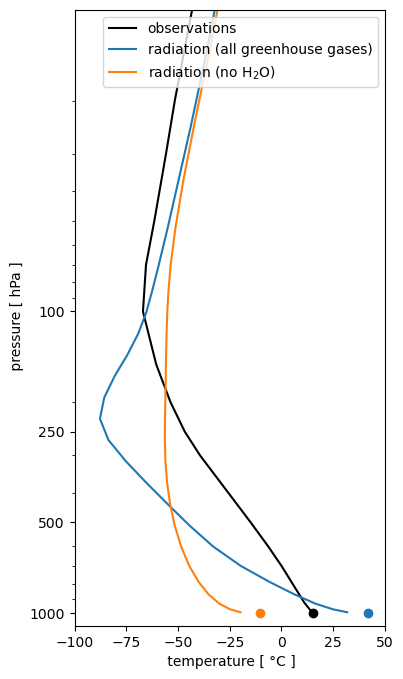

In [39]:
plt.figure(figsize=(4,8))
plt.plot(T_global,T_global.level,c='k',label='observations')
plt.plot(T_global[0],T_global.level[0],'ko')

plt.plot(radmodel.Tatm-273.15,radmodel.lev,c='C0',
         label='radiation (all greenhouse gases)')
plt.plot(radmodel.Ts-273.15,1000,'o')

plt.plot(radmodel_noH2O.Tatm-273.15,radmodel_noH2O.lev,c='C1',
         label='radiation (no H$_2$O)')
plt.plot(radmodel_noH2O.Ts-273.15,1000,'o')

ax=plt.gca()
ax.invert_yaxis()
ax.set_yscale('log')
ax.set_yticks([100, 250, 500, 1000])
ax.set_ylim(1100,10)
ax.set_xticks(np.arange(-100,75,25))
ax.get_yaxis().set_major_formatter(ScalarFormatter())
plt.ylabel(' pressure [ hPa ]')
plt.xlabel(' temperature [ °C ]')
plt.legend()

**Describe what happened to the profile of temperature. Why did this occur? What can you learn from this about the radiative role of water vapor?**

<b> Answer: </b>

<div class="alert alert-block alert-warning">

## What Happened to the Profile?

Removing water vapor had two dramatic, opposite effects at different altitudes:

1.  **The Surface Cooled:** The surface temperature (at 1000 hPa) dropped massively, from its "all gases" equilibrium of ~42°C (blue dot) to a new equilibrium of about **-20°C** (orange dot).
2.  **The Troposphere Warmed:** The air in the troposphere (from ~800 hPa to 150 hPa) became significantly **warmer**. The extreme cold "dip" seen in the "all gases" model (which went below -75°C) disappeared, and the profile became much straighter.
3.  **The Stratosphere Was Unchanged:** Above ~150 hPa, the temperature profile is almost identical to the "all gases" model.

---

## Why This Occurred

This teaches us that water vapor plays **two major radiative roles** in the atmosphere: one for the surface and another for the air.

1.  **It's a Powerful Greenhouse Gas (Warms the Surface):** Water vapor is extremely effective at absorbing the longwave radiation emitted by the Earth and radiating it back down. When we removed $H_2O$, we essentially removed most of the "greenhouse blanket." The surface could then radiate its heat directly to space, causing it to cool down to a frigid -20°C.

2.  **It's the Main Tropospheric Coolant (Cools the Air):** In a pure radiative equilibrium, the troposphere itself loses energy by emitting radiation to space. Water vapor is the primary gas responsible for this emission. In your "all gases" model (blue line), the $H_2O$ in the troposphere was cooling that layer so effectively it reached -90°C. When we removed $H_2O$, we "turned off" this cooling mechanism. With no way to lose heat, the troposphere warmed up significantly.

The **stratosphere** was unaffected because, as we saw in the earlier plot, it contains almost no water vapor to begin with. Its temperature is set by the balance of ozone ($O_3$) and carbon dioxide ($CO_2$).

</div>

#### Radiative equilibrium without ozone
Following the steps above, make another model, but this time instead of removing the water vapor, remove ozone. Make another plot that includes the new profile along with the other profiles.

In [40]:
# --- code ---
# Create a clone of the original model
radmodel_noO3 = climlab.process_like(radmodel)
radmodel_noO3.name = 'Radiation (no O3)'

# Set the ozone concentration to zero
# The absorber_vmr dictionary is mutable, so we can modify it directly
radmodel_noO3.absorber_vmr['O3'] *= 0.

# Run this new model to equilibrium
radmodel_noO3.step_forward()
while np.abs(radmodel_noO3.ASR - radmodel_noO3.OLR) > 0.01:
    radmodel_noO3.step_forward()
# ---

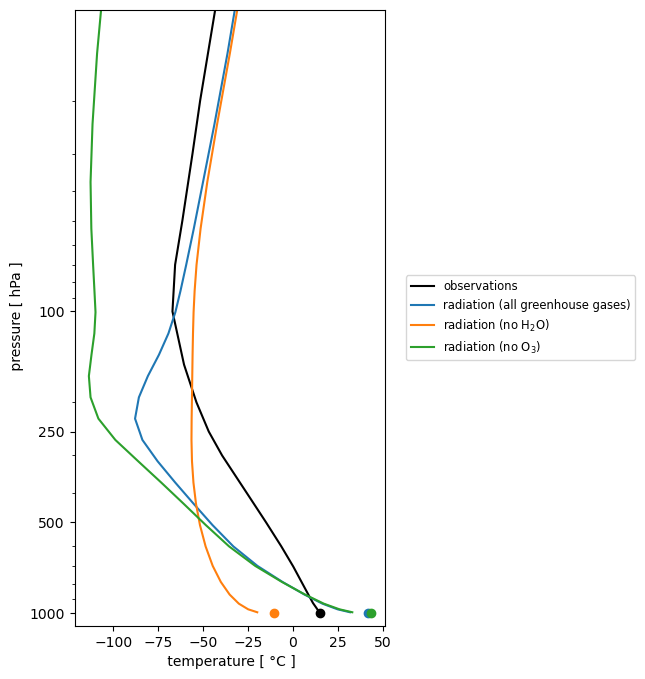

In [41]:
# --- plot ---
plt.figure(figsize=(4,8))
ax = plt.gca()

# Plot observations (black)
plt.plot(T_global,T_global.level,c='k',label='observations')
plt.plot(T_global[0],T_global.level[0],'ko')

# Plot radiation (all gases) (blue, 'C0')
plt.plot(radmodel.Tatm-273.15,radmodel.lev,c='C0',
         label='radiation (all greenhouse gases)')
plt.plot(radmodel.Ts-273.15,1000,'o', c='C0')

# Plot radiation (no H2O) (orange, 'C1')
plt.plot(radmodel_noH2O.Tatm-273.15,radmodel_noH2O.lev,c='C1',
         label='radiation (no H$_2$O)')
plt.plot(radmodel_noH2O.Ts-273.15,1000,'o', c='C1')

# Plot radiation (no O3) (green, 'C2')
plt.plot(radmodel_noO3.Tatm-273.15,radmodel_noO3.lev,c='C2',
         label='radiation (no O$_3$)')
plt.plot(radmodel_noO3.Ts-273.15,1000,'o', c='C2')

# Set plot properties
# Move legend outside the plot
plt.legend(loc='center left', bbox_to_anchor=(1.05, 0.5), fontsize='small')
plt.ylabel(' pressure [ hPa ]')
plt.xlabel(' temperature [ °C ]')
ax.invert_yaxis()
ax.set_yscale('log')
ax.set_yticks([100, 250, 500, 1000])
ax.set_ylim(1100,10)
ax.set_xticks(np.arange(-100,75,25))
ax.get_yaxis().set_major_formatter(ScalarFormatter())
# ---

**Describe what happened to the profile of temperature. Why did this occur? Were the changes uniform?**

<b> Answer: </b>

<div class="alert alert-block alert-warning">

### What Happened to the Profile?

The changes were **not uniform** at all; they were almost exclusively in the stratosphere.

* **The Stratosphere (above ~150 hPa):** The temperature collapsed. Instead of hovering around -50°C to -60°C, the "no $O_3$" profile (green line) plummeted to below -90°C, becoming much colder than even the "all gases" model.
* **The Troposphere and Surface (below ~150 hPa):** This region was **almost completely unaffected**. The green line and the blue line ("all greenhouse gases") are nearly identical from the surface (1000 hPa) up to the tropopause (~150 hPa).

---

### Why This Occurred

**Ozone's main job is to heat the stratosphere.** The stratosphere is in radiative equilibrium, and its temperature is set by a balance between heating and cooling.

1.  **Heating:** Ozone is the primary gas that **absorbs incoming shortwave (solar) UV radiation**. This absorption of sunlight is what heats the stratosphere and creates the temperature inversion (where temperature stops dropping and starts to rise).
2.  **Cooling:** This heating is balanced by cooling from gases like $CO_2$ emitting longwave radiation.

By removing ozone, we **turned off the primary heat source for the stratosphere**. The cooling processes (from $CO_2$) were still active, so the stratosphere's temperature crashed to a new, much colder equilibrium. The troposphere and surface didn't change because ozone's heating role is not significant at those lower altitudes, where convection and water vapor dominate the energy budget.

</div>

#### Radiative equilibrium without methane
Following the steps above, make another model, but this time instead of removing the water vapor or ozone, remove the methane.  Make another plot that includes the new profile along with the other profiles.

In [42]:
# --- code ---
# Create a clone of the original model
radmodel_noCH4 = climlab.process_like(radmodel)
radmodel_noCH4.name = 'Radiation (no CH4)'

# Set the methane concentration to zero
radmodel_noCH4.absorber_vmr['CH4'] = 0.

# Run this new model to equilibrium
radmodel_noCH4.step_forward()
while np.abs(radmodel_noCH4.ASR - radmodel_noCH4.OLR) > 0.01:
    radmodel_noCH4.step_forward()
# ---

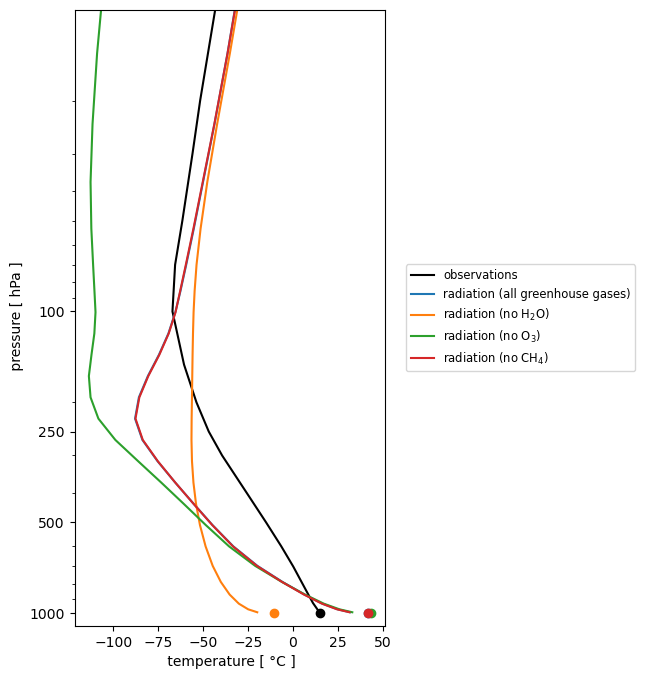

In [43]:
# --- plot ---
plt.figure(figsize=(4,8))
ax = plt.gca()

# Plot observations (black)
plt.plot(T_global, T_global.level, c='k', label='observations')
plt.plot(T_global[0], T_global.level[0], 'ko')

# Plot radiation (all gases) (blue, 'C0')
plt.plot(radmodel.Tatm-273.15, radmodel.lev, c='C0', label='radiation (all greenhouse gases)')
plt.plot(radmodel.Ts-273.15, 1000, 'o', c='C0')

# Plot radiation (no H2O) (orange, 'C1')
plt.plot(radmodel_noH2O.Tatm-273.15, radmodel_noH2O.lev, c='C1', label='radiation (no H$_2$O)')
plt.plot(radmodel_noH2O.Ts-273.15, 1000, 'o', c='C1')

# Plot radiation (no O3) (green, 'C2')
plt.plot(radmodel_noO3.Tatm-273.15, radmodel_noO3.lev, c='C2', label='radiation (no O$_3$)')
plt.plot(radmodel_noO3.Ts-273.15, 1000, 'o', c='C2')

# Plot radiation (no CH4) (red, 'C3')
plt.plot(radmodel_noCH4.Tatm-273.15, radmodel_noCH4.lev, c='C3', label='radiation (no CH$_4$)')
plt.plot(radmodel_noCH4.Ts-273.15, 1000, 'o', c='C3')

# Set plot properties
plt.ylabel(' pressure [ hPa ]')
plt.xlabel(' temperature [ °C ]')
# Move legend outside the plot
plt.legend(loc='center left', bbox_to_anchor=(1.05, 0.5), fontsize='small')
ax.invert_yaxis()
ax.set_yscale('log')
ax.set_yticks([100, 250, 500, 1000])
ax.set_ylim(1100,10)
ax.set_xticks(np.arange(-100,75,25))
ax.get_yaxis().set_major_formatter(ScalarFormatter())
# ---

**Describe what happened to the profile of temperature. Why did this occur? Were the changes uniform?**

<b> Answer: </b>

<div class="alert alert-block alert-warning">

Based on the plot, **removing methane ($CH_4$) had an almost imperceptible effect** on the temperature profile. The red line ("no $CH_4$") is nearly identical to the blue line ("all greenhouse gases").

**Why did this occur?** This tiny change is due to methane's **very low concentration** in the model. While methane is a potent greenhouse gas, its specified concentration is only **1.65 ppmv**. This is over 200 times less than the $CO_2$ concentration of **348 ppmv**. Because methane's concentration is so small, its total contribution to the greenhouse effect is minor compared to the dominant roles of water vapor and $CO_2$. Removing it only results in a tiny, uniform cooling (a fraction of a degree) that is not visible at the scale of this plot.

**Were the Changes Uniform?** Yes, the very small change that did occur would be uniform. Unlike water vapor or ozone, methane is a **well-mixed gas**, so its small warming effect is distributed throughout the atmospheric column.

</div>

#### Radiative equilibrium without carbon-dioxide
Following the steps above, make another model, but this time instead of removing the water vapor or ozone, remove the carbon-dioxide. Make another plot that includes the new profile along with the other profiles.

In [44]:
# --- code ---
# Create a clone of the original model
radmodel_noCO2 = climlab.process_like(radmodel)
radmodel_noCO2.name = 'Radiation (no CO2)'

# Set the carbon dioxide concentration to zero
radmodel_noCO2.absorber_vmr['CO2'] = 0.

# Run this new model to equilibrium
radmodel_noCO2.step_forward()
while np.abs(radmodel_noCO2.ASR - radmodel_noCO2.OLR) > 0.01:
    radmodel_noCO2.step_forward()
# ---

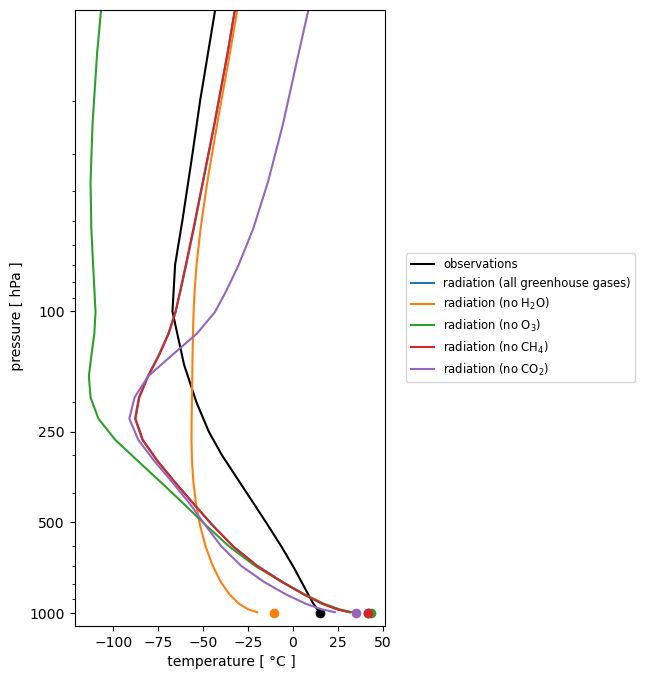

In [45]:
# --- plot ---
plt.figure(figsize=(4,8))
ax = plt.gca()

# Plot observations (black)
plt.plot(T_global, T_global.level, c='k', label='observations')
plt.plot(T_global[0], T_global.level[0], 'ko')

# Plot radiation (all gases) (blue, 'C0')
plt.plot(radmodel.Tatm-273.15, radmodel.lev, c='C0', 
         label='radiation (all greenhouse gases)')
plt.plot(radmodel.Ts-273.15, 1000, 'o', c='C0')

# Plot radiation (no H2O) (orange, 'C1')
plt.plot(radmodel_noH2O.Tatm-273.15, radmodel_noH2O.lev, c='C1', 
         label='radiation (no H$_2$O)')
plt.plot(radmodel_noH2O.Ts-273.15, 1000, 'o', c='C1')

# Plot radiation (no O3) (green, 'C2')
plt.plot(radmodel_noO3.Tatm-273.15, radmodel_noO3.lev, c='C2', 
         label='radiation (no O$_3$)')
plt.plot(radmodel_noO3.Ts-273.15, 1000, 'o', c='C2')

# Plot radiation (no CH4) (red, 'C3')
plt.plot(radmodel_noCH4.Tatm-273.15, radmodel_noCH4.lev, c='C3', 
         label='radiation (no CH$_4$)')
plt.plot(radmodel_noCH4.Ts-273.15, 1000, 'o', c='C3')

# Plot radiation (no CO2) (purple, 'C4')
plt.plot(radmodel_noCO2.Tatm-273.15, radmodel_noCO2.lev, c='C4', 
         label='radiation (no CO$_2$)')
plt.plot(radmodel_noCO2.Ts-273.15, 1000, 'o', c='C4')

# Set plot properties
plt.ylabel(' pressure [ hPa ]')
plt.xlabel(' temperature [ °C ]')
# Move legend outside the plot
plt.legend(loc='center left', bbox_to_anchor=(1.05, 0.5), fontsize='small')
ax.invert_yaxis()
ax.set_yscale('log')
ax.set_yticks([100, 250, 500, 1000])
ax.set_ylim(1100,10)
ax.set_xticks(np.arange(-100,75,25))
ax.get_yaxis().set_major_formatter(ScalarFormatter())
# ---

**Describe what happened to the profile of temperature. Why did this occur? Were the changes uniform?**

<b> Answer: </b>

<div class="alert alert-block alert-warning">

### What Happened to the Profile?

The changes were **not uniform** and were almost entirely confined to the stratosphere.

* **Troposphere and Surface (1000 hPa to ~150 hPa):** **Almost nothing happened.** The "no $CO_2$" profile (purple) is right on top of the "all gases" profile (blue). The surface temperature and the deep tropospheric cold dip are nearly the same.
* **Stratosphere (above ~150 hPa):** This region became **significantly warmer**. By removing $CO_2$, the temperature increased from around -60°C to -25°C.

---

### Why This Occurred

1.  **In the Troposphere (Why no change?):** The radiative physics of the troposphere are completely **dominated by water vapor ($H_2O$)**. $H_2O$ is such a powerful greenhouse gas and coolant that it "masks" the effect of $CO_2$. Both gases absorb in similar longwave regions, so removing the 348 ppmv of $CO_2$ has very little effect on the overall energy balance, which is already controlled by $H_2O$.
2.  **In the Stratosphere (Why did it warm up?):** The stratosphere is in radiative equilibrium, and its temperature is set by a balance between heating and cooling.
    * **Heating:** from Ozone ($O_3$) absorbing solar UV.
    * **Cooling:** from $CO_2$ emitting longwave radiation to space.

    By removing $CO_2$, we effectively **turned off the stratosphere's primary cooling mechanism**. The heating from ozone was no longer balanced, so the stratosphere's temperature rose dramatically to a new, warmer equilibrium.

</div>

#### Let's summarize our radiative equilibrium results

- We used the `RRTMG` radiation model with prescribed profiles of absorbing gases to calculate **pure radiative equilibrium** temperature profiles.
- Radiative equilibrium means the temperatures that the surface and air column would have **if radiation was the only physical process that could transfer energy between levels**.
- We computed several different radiative equilibrium profiles, with and without key absorbing gases

However, the key takeaway message is that **none of these radiative equilibrium profiles look much like the observations in the troposphere**.

This strongly suggests that other physical processes (aside from radiation) are important in determining the observed temperature profile. Moreover, if we were to plot these profiles on a skew-T diagram, it would become clear that all the radiative equilibrium profiles are statically unstable near the surface. So we're now going to add a representation of the effects of convective mixing to the single-column model.

#### Building a radiative-convection model in climlab 
To make a Radiative-Convective model, we just take a radiation model and couple it to a convection model.

The "convection" model we're going to use here is available as `climlab.convection.ConvectiveAdjustment`. It is a simple process that looks for lapse rates exceeding a critical threshold and performs an instantaneous adjustment that mixes temperatures to the critical lapse rate while conserving energy. This is a parameterization of the complex, rapid mixing processes that actually occur in an unstable air column.

Here is some code to put this model together in climlab:

In [46]:
mystate = climlab.column_state(lev=level, water_depth=2.5)
#  Build the radiation model -- just like we already did
rad = climlab.radiation.RRTMG(name='Radiation (net)',
                              state=mystate, 
                              specific_humidity=Q_global,
                              timestep = climlab.constants.seconds_per_day,
                              # surface albedo, tuned to give reasonable ASR 
                              # for reference cloud-free model
                              albedo = 0.25,  
                             )
#  Now create the convection model
conv = climlab.convection.ConvectiveAdjustment(name='Convection',
                                               state=mystate,
                                               # this is the key parameter! 
                                               # We'll discuss below
                                               adj_lapse_rate=6.5, 
                                               # same timestep!
                                               timestep=rad.timestep,  
                                              )
#  Here is where we build the model by coupling together the two components
rcm = climlab.couple([rad, conv], name='Radiative-Convective Model')


In [47]:
print(rcm)

climlab Process of type <class 'climlab.process.time_dependent_process.TimeDependentProcess'>. 
State variables and domain shapes: 
  Ts: (1,) 
  Tatm: (26,) 
The subprocess tree: 
Radiative-Convective Model: <class 'climlab.process.time_dependent_process.TimeDependentProcess'>
   Radiation (net): <class 'climlab.radiation.rrtm.rrtmg.RRTMG'>
      SW: <class 'climlab.radiation.rrtm.rrtmg_sw.RRTMG_SW'>
      LW: <class 'climlab.radiation.rrtm.rrtmg_lw.RRTMG_LW'>
   Convection: <class 'climlab.convection.convadj.ConvectiveAdjustment'>



To make this a bit more interactive, we are going to define some functions. You can ignore these, but feel free to make sense of the code.

In [48]:
from IPython.display import HTML
from matplotlib import animation
import numpy as np
import matplotlib.pyplot as plt
import xarray as xr
from metpy.plots import SkewT
#  This code is used just to create the skew-T plot of global, annual mean 
#  air temperature
ncep_url = "http://www.esrl.noaa.gov/psd/thredds/dodsC/Datasets/ncep.\
reanalysis.derived/"
ncep_air = xr.open_dataset( ncep_url + "pressure/air.mon.1981-2010.ltm.nc", 
                           use_cftime=True)
#  Take global, annual average 
coslat = np.cos(np.deg2rad(ncep_air.lat))
weight = coslat / coslat.mean(dim='lat')
Tglobal = (ncep_air.air * weight).mean(dim=('lat','lon','time'))
#  Resuable function to plot the temperature data on a Skew-T chart
def make_skewT():
    fig = plt.figure(figsize=(9, 9))
    skew = SkewT(fig, rotation=30)
    skew.plot(Tglobal.level, Tglobal, color='black', linestyle='-', 
              linewidth=2, label='Observations')
    skew.ax.set_ylim(1050, 10)
    skew.ax.set_xlim(-90, 45)
    # Add the relevant special lines
    skew.plot_dry_adiabats(linewidth=0.5)
    skew.plot_moist_adiabats(linewidth=0.5)
    #skew.plot_mixing_lines()
    skew.ax.legend()
    skew.ax.set_xlabel('Temperature (degC)', fontsize=14)
    skew.ax.set_ylabel('Pressure (hPa)', fontsize=14)
    return skew
#  and a function to add extra profiles to this chart
def add_profile(skew, model, linestyle='-', color=None):
    line = skew.plot(model.lev, model.Tatm - climlab.constants.tempCtoK,
             label=model.name, linewidth=2)[0]
    skew.plot(1000, model.Ts - climlab.constants.tempCtoK, 'o', 
              markersize=8, color=line.get_color())
    skew.ax.legend()

def get_tendencies(model):
    '''Pack all the subprocess tendencies into xarray.Datasets
    and convert to units of K / day'''
    tendencies_atm = xr.Dataset()
    tendencies_sfc = xr.Dataset()
    for name, proc, top_proc in climlab.utils.walk.walk_processes(
        model, topname='Total', topdown=False):
        tendencies_atm[name] = proc.tendencies['Tatm'].to_xarray()
        tendencies_sfc[name] = proc.tendencies['Ts'].to_xarray()
    for tend in [tendencies_atm, tendencies_sfc]:
        #  convert to K / day
        tend *= climlab.constants.seconds_per_day
    return tendencies_atm, tendencies_sfc

def initial_figure(model):
    fig = plt.figure(figsize=(14,6))
    lines = []
    
    skew = SkewT(fig, subplot=(1,2,1), rotation=30)
    #  plot the observations
    skew.plot(Tglobal.level, Tglobal, color='black', linestyle='-', 
              linewidth=2, label='Observations')    
    lines.append(skew.plot(model.lev, model.Tatm - climlab.constants.tempCtoK, 
              linestyle='-', linewidth=2, color='C0', 
              label='RC model (all gases)')[0])
    skew.ax.legend()
    skew.ax.set_ylim(1050, 10)
    skew.ax.set_xlim(-60, 75)
    # Add the relevant special lines
    skew.plot_dry_adiabats(linewidth=0.5)
    skew.plot_moist_adiabats(linewidth=0.5)
    skew.ax.set_xlabel('Temperature ($^\circ$C)', fontsize=14)
    skew.ax.set_ylabel('Pressure (hPa)', fontsize=14)
    lines.append(skew.plot(1000, model.Ts - climlab.constants.tempCtoK, 'o', 
                  markersize=8, color='C0', )[0])

    ax = fig.add_subplot(1,2,2, sharey=skew.ax)
    ax.set_ylim(1050, 10)
    ax.set_xlim(-8,8)
    ax.grid()
    ax.set_xlabel('Temperature tendency ($^\circ$C day$^{-1}$)', fontsize=14)

    color_cycle=['g','b','r','y','k']
    #color_cycle=['y', 'r', 'b', 'g', 'k']
    tendencies_atm, tendencies_sfc = get_tendencies(rcm)
    for i, name in enumerate(tendencies_atm.data_vars):
        lines.append(ax.plot(tendencies_atm[name], model.lev, label=name, 
                             color=color_cycle[i])[0])
    for i, name in enumerate(tendencies_sfc.data_vars):
        lines.append(ax.plot(tendencies_sfc[name], 1000, 'o', markersize=8, 
                             color=color_cycle[i])[0])
    ax.legend(loc='center right')
    lines.append(skew.ax.text(-100, 50, 'Day {}'.format(int(
        model.time['days_elapsed'])), fontsize=12)) 
    return fig, lines

def animate(day, model, lines):
    lines[0].set_xdata(np.array(model.Tatm)-climlab.constants.tempCtoK)
    lines[1].set_xdata(np.array(model.Ts)-climlab.constants.tempCtoK)
    #lines[2].set_xdata(np.array(model.q)*1E3)
    tendencies_atm, tendencies_sfc = get_tendencies(model)
    for i, name in enumerate(tendencies_atm.data_vars):
        lines[2+i].set_xdata(tendencies_atm[name])
    for i, name in enumerate(tendencies_sfc.data_vars):
        lines[2+5+i].set_xdata(tendencies_sfc[name])
    lines[-1].set_text('Day {}'.format(int(model.time['days_elapsed'])))
    # This is kind of a hack, but without it the initial frame doesn't appear
    if day != 0:
        model.step_forward()
    return lines

<>:72: SyntaxWarning: invalid escape sequence '\c'
<>:81: SyntaxWarning: invalid escape sequence '\c'
<>:72: SyntaxWarning: invalid escape sequence '\c'
<>:81: SyntaxWarning: invalid escape sequence '\c'
/var/folders/tr/k0y0wc3s1m5_wwth47rgzlq80000gn/T/ipykernel_84788/736758083.py:72: SyntaxWarning: invalid escape sequence '\c'
  skew.ax.set_xlabel('Temperature ($^\circ$C)', fontsize=14)
/var/folders/tr/k0y0wc3s1m5_wwth47rgzlq80000gn/T/ipykernel_84788/736758083.py:81: SyntaxWarning: invalid escape sequence '\c'
  ax.set_xlabel('Temperature tendency ($^\circ$C day$^{-1}$)', fontsize=14)
/var/folders/tr/k0y0wc3s1m5_wwth47rgzlq80000gn/T/ipykernel_84788/736758083.py:11: DeprecationWarning: Usage of 'use_cftime' as a kwarg is deprecated. Please pass a 'CFDatetimeCoder' instance initialized with 'use_cftime' to the 'decode_times' kwarg instead.
Example usage:
    time_coder = xr.coders.CFDatetimeCoder(use_cftime=True)
    ds = xr.open_dataset(decode_times=time_coder)

  ncep_air = xr.open_da

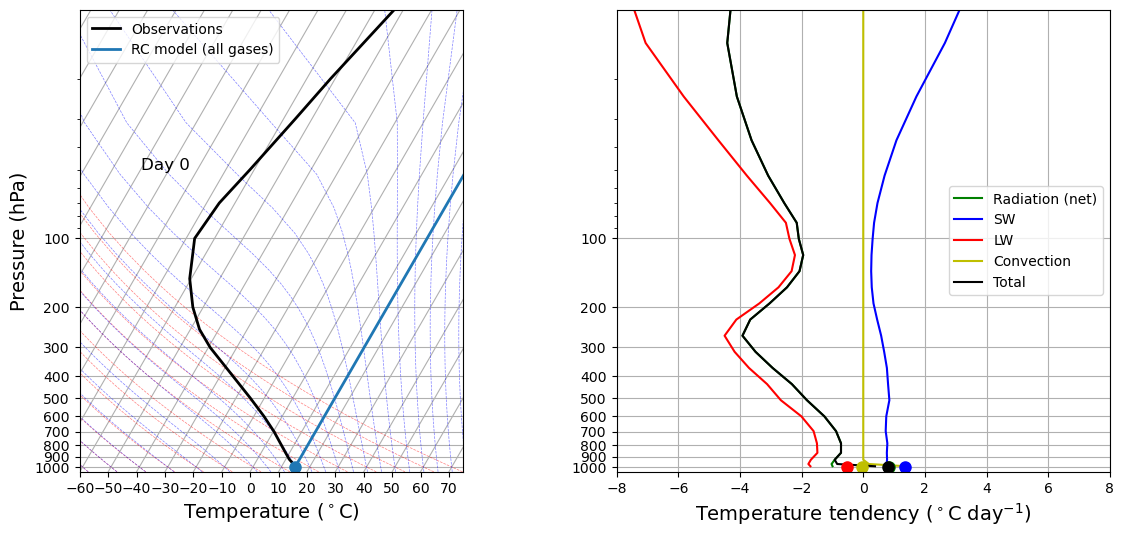

In [49]:
#  Start from isothermal state
rcm.state.Tatm[:] = rcm.state.Ts
#  Call the diagnostics once for initial plotting
rcm.compute_diagnostics()
#  Plot initial data
fig, lines = initial_figure(rcm)

**Before we get started, let's try and understand a few things.**
- The initial tendency from convection is zero everywhere. Why?
- Shortwave radiation tends to warm everywhere. Why?
- Longwave radiation tends to cool everywhere. The cooling is very strong especially aloft. Why?
- The total tendency (black) is warming at the surface and cooling in the atmosphere. What should happen next? What are the implications for convective instability?

<b> Answer: </b>

<div class="alert alert-block alert-warning">

### Why is the initial convection tendency zero?

The `ConvectiveAdjustment` process only activates when the lapse rate is **steeper** (more unstable) than the `adj_lapse_rate` (which is set to 6.5 K/km). The model was initialized in an **isothermal state** (`rcm.state.Tatm[:] = rcm.state.Ts`), meaning the temperature is the same at all altitudes. This profile has a lapse rate of **0 K/km**, which is much less than 6.5 K/km. Since the atmosphere is perfectly stable, there is no convection, and the tendency is zero.

### Why does shortwave radiation tend to warm everywhere?

Shortwave radiation is **incoming solar energy**. The atmosphere (especially ozone and water vapor) and the surface absorb this energy. Since this is a heating process, it shows up as a positive tendency (warming) wherever sunlight is being absorbed.

### Why does longwave radiation tend to cool everywhere?

Longwave radiation is **outgoing thermal energy** emitted by the Earth's surface and atmosphere.

* In the **troposphere**, greenhouse gases (especially water vapor) are very effective at emitting this radiation. This emission of energy to space (and to other layers) is a cooling process.
* The cooling is **strongest aloft** (higher in the atmosphere) because the air there is very thin (low pressure). It can radiate heat away easily but doesn't have much mass above it to radiate heat *back down*, leading to very efficient net cooling.

### What should happen next?

The plot shows the **total tendency** (black line) is:
* **Warming** at the surface (positive tendency).
* **Cooling** in the atmosphere (negative tendency).

This means the **surface will get hotter** and the **air will get colder**. This will immediately create a very steep, unstable lapse rate (hot air below cold air). This instability will **trigger the convective adjustment** process, which will start mixing the heat from the surface upward into the atmosphere, fighting the radiative cooling and forcing the profile toward the 6.5 K/km lapse rate.

</div>

Now, let's make an animation to see what would happen if we ran this equilibrium.

In [58]:
# This cell may take a few minutes to run
#  This is where we make a loop over many timesteps and create an animation in 
#  the notebook
ani = animation.FuncAnimation(fig, animate, 365, fargs=(rcm, lines))
HTML(ani.to_html5_video())

**How does the profile adjust as time goes on? What does this imply about the relative role of convection versus radiation?**

<b> Answer: </b>

<div class="alert alert-block alert-warning">

### How the Profile Adjusts

1.  **Initial State:** The model starts in an isothermal state (the vertical blue line), where the temperature is the same from the surface to the top of the atmosphere.
2.  **Radiation Takes Over:** Instantly, radiation begins to act. As the tendency plot showed, longwave radiation (green line) starts to **cool the entire atmosphere**, while shortwave radiation (blue line) and the surface flux **warm the surface** (red line).
3.  **Convection Activates:** This creates a highly unstable state (hot surface, cold air). Convection (the yellow line, `Convection`) immediately turns on to fight this instability. It begins **aggressively warming the atmosphere** by taking the excess heat from the surface and mixing it upward.
4.  **Finding Equilibrium:** The profile quickly settles into a two-part structure:
    * **Troposphere (1000 hPa to ~100 hPa):** The temperature (blue line) no longer follows the initial unstable radiative profile. Instead, it "snaps" to a much warmer, straighter line that is **parallel to the observed profile** (black line). This new line represents the `adj_lapse_rate` of 6.5 K/km.
    * **Stratosphere (above ~100 hPa):** The temperature profile (blue line) breaks away from the 6.5 K/km slope and follows its own path, which is set by **pure radiative equilibrium**. This part of the profile is much closer to the observations (black line).

---

### What This Implies

This equilibrium plot implies that the atmosphere is governed by two different sets of rules:

1.  **Convection Dominates the Troposphere:** The real-world troposphere is not in pure radiative equilibrium because that state is unstable. Convection (and other vertical motions) takes over, mixes the air, and forces the temperature profile to follow a stable lapse rate. This is why the model's troposphere (blue line) matches the **slope** of the observed troposphere (black line) so well.
2.  **Radiation Dominates the Stratosphere:** The stratosphere is stable, so convection doesn't happen there. In that layer, the temperature is determined by a pure balance of radiative heating (from $O_3$) and cooling (from $CO_2$). This is why the model's stratospheric profile is realistic.

In short, **convection sets the lapse rate (slope) of the troposphere, while radiation sets the temperature of the stratosphere.**

</div>

Now, let's do the same analysis as above, but with the new model. Here, we are providing you with code that computes the equilibrium profile of temperature from the RCE.

In [51]:
rcemodel = climlab.process_like(rcm)

In [52]:
while np.abs(rcemodel.ASR - rcemodel.OLR) > 0.01:
    rcemodel.step_forward()

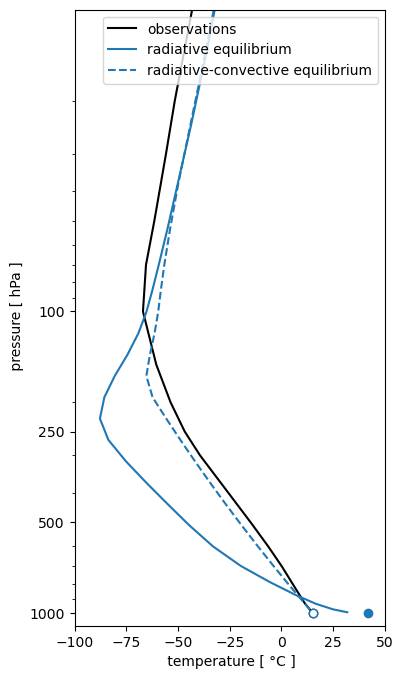

In [53]:
plt.figure(figsize=(4,8))
plt.plot(T_global,T_global.level,c='k',label='observations')
plt.plot(T_global[0],T_global.level[0],'ko')

plt.plot(radmodel.Tatm-273.15,radmodel.lev,c='C0',
         label='radiative equilibrium')
plt.plot(radmodel.Ts-273.15,1000,'o')


plt.plot(rcemodel.Tatm-273.15,rcemodel.lev,c='C0',ls='--',
         label='radiative-convective equilibrium')
plt.plot(rcemodel.Ts-273.15,1000,'o',c='C0',markerfacecolor='white')

ax=plt.gca()
ax.invert_yaxis()
ax.set_yscale('log')
ax.set_yticks([100, 250, 500, 1000])
ax.set_ylim(1100,10)
ax.set_xticks(np.arange(-100,75,25))
ax.get_yaxis().set_major_formatter(ScalarFormatter())
plt.ylabel(' pressure [ hPa ]')
plt.xlabel(' temperature [ °C ]')
plt.legend()

**Why does the radiative-convective profile look better? What processes are acting to change the vertical temperature gradient?**

<b> Answer: </b>

<div class="alert alert-block alert-warning">

### Why the Radiative-Convective Profile Looks Better

The radiative-convective profile (dashed line) looks much better because it **correctly simulates the troposphere**. Unlike the "radiative equilibrium" model (solid blue line) which produced a surface temperature over $40\degree\text{C}$ and a mid-troposphere colder than $-75\degree\text{C}$, the radiative-convective profile brings the surface temperature down and warms the troposphere, making it a much closer match to the real-world observations (black line).

---

### Processes Changing the Temperature Gradient

The vertical temperature gradient (lapse rate) is being changed by the balance of two competing processes:

1.  **Radiation:** As we saw in the pure radiative model, radiation alone **tries to make the atmosphere unstable**. It cools the troposphere (especially the upper troposphere) very strongly and heats the surface, creating a very steep, unstable temperature gradient.
2.  **Convection:** The `ConvectiveAdjustment` process prevents this. As soon as the lapse rate becomes steeper than the 6.5 K/km limit, convection kicks in. It acts as a **vertical mixing** process, taking heat from the hot surface and transporting it upward, which **cools the surface** and **warms the troposphere**.

The final profile is the equilibrium between these two: radiation constantly tries to destabilize the profile, and convection constantly mixes it back to the stable 6.5 K/km lapse rate.

</div>

**Now, perform the same analyses above. Remove water vapor, ozone, methane, and carbon-dioixe individually. Make a plot that shows radiative equilibrium and radiative-convective equilibrium of each of these.**

**Describe the key differences and explain why this occurs.**

<b> Answer: </b>

<div class="alert alert-block alert-warning">

1.  **RE (Solid) vs. RCE (Dashed):** The biggest difference is that all the **RCE (dashed)** profiles are clustered together and follow a stable, uniform slope (the 6.5 K/km lapse rate). The **RE (solid)** profiles are wildly unstable, with extremely hot surfaces and cold tropospheres.
    * **Why:** The RCE model adds **convection** **(Schneider ch. 6, pg. 178)**. This process dominates the troposphere by mixing heat upward, forcing the atmosphere into a stable "radiative-convective equilibrium" that is much more realistic.

2.  **The Role of Water Vapor (Orange):** The "no $H_2O$" (orange) lines are **identical**. The solid RE line is the same as the dashed RCE line.
    * **Why:** Water vapor is the most important greenhouse gas for creating instability. Without $H_2O$, the atmosphere isn't unstable enough to trigger convection. The radiative equilibrium profile is *already stable*, so the convective adjustment process never turns on.

3.  **The Stratosphere (Ozone vs. CO2):** The gases show opposite effects in the stratosphere (above ~150 hPa).
    * Removing **$O_3$ (green)** causes the stratosphere to become **extremely cold**.
    * Removing **$CO_2$ (purple)** causes the stratosphere to become **extremely warm**.
    * **Why:** The stratosphere's temperature *is* in radiative equilibrium, set by a balance between $O_3$ absorbing sunlight (heating) and $CO_2$ emitting heat (cooling) **(Hartmann ch. 3, pg. 82)**. Removing the heater ($O_3$) makes it cold; removing the cooler ($CO_2$) makes it hot.

</div>

Now, as a final exercise let's double carbon-dioxide and estimate the amount of warming. This is a highly sought after question in the field and still a quite uncertain quantity. It is known as the equilibirum climate sensetivity (ECS) or how much the Earth will warm for doubling of $\text{CO}_2$ concentrations. To do this double the $\text{CO}_2$ concentraiton and run the model forward in time. Make sure the other gases are the orginal concentration. Plot the resulting vertical profile.

Running 2xCO2 model to equilibrium (this may take a moment)...
2xCO2 model is in equilibrium.
Original RCE Surface Temperature (1xCO2): 15.30 C
Doubled RCE Surface Temperature (2xCO2): 16.59 C
Equilibrium Climate Sensitivity (Warming): +1.29 C
Generating plot...


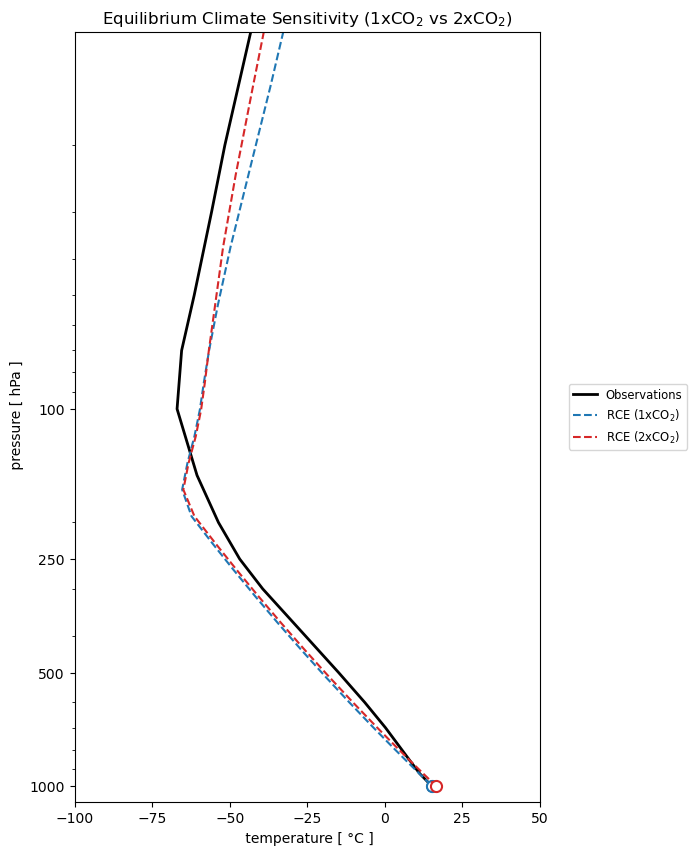

In [55]:
# --- code ---
# Create a clone of the original RCE model
rcemodel_2xCO2 = climlab.process_like(rcemodel)
rcemodel_2xCO2.name = 'RCE (2xCO2)'

# Double the CO2 concentration in the radiation subprocess
rcemodel_2xCO2.subprocess['Radiation (net)'].absorber_vmr['CO2'] *= 2.0

print("Running 2xCO2 model to equilibrium (this may take a moment)...")
# Run this new model to equilibrium
rcemodel_2xCO2.step_forward()
while np.abs(rcemodel_2xCO2.ASR - rcemodel_2xCO2.OLR) > 0.01:
    rcemodel_2xCO2.step_forward()

print("2xCO2 model is in equilibrium.")

# --- Print the resulting surface temperatures ---
original_Ts = rcemodel.Ts[0] - 273.15
doubled_Ts = rcemodel_2xCO2.Ts[0] - 273.15
warming = doubled_Ts - original_Ts

print(f"Original RCE Surface Temperature (1xCO2): {original_Ts:.2f} C")
print(f"Doubled RCE Surface Temperature (2xCO2): {doubled_Ts:.2f} C")
print(f"Equilibrium Climate Sensitivity (Warming): +{warming:.2f} C")

# --- plot ---
print("Generating plot...")
plt.figure(figsize=(6, 10))
ax = plt.gca()

# Plot Observations (black)
ax.plot(T_global, T_global.level, c='k', ls='-', lw=2, label='Observations')
ax.plot(T_global[0], T_global.level[0], 'ko', markersize=8)

# Plot RCE (1xCO2) (blue dashed)
ax.plot(rcemodel.Tatm - 273.15, rcemodel.lev, c='C0', ls='--', 
        label='RCE (1xCO$_2$)')
ax.plot(rcemodel.Ts - 273.15, 1000, 'o', c='C0', markersize=8, 
        markerfacecolor='white', markeredgewidth=1.5)

# Plot RCE (2xCO2) (red dashed)
ax.plot(rcemodel_2xCO2.Tatm - 273.15, rcemodel_2xCO2.lev, c='C3', ls='--', 
        label='RCE (2xCO$_2$)')
ax.plot(rcemodel_2xCO2.Ts - 273.15, 1000, 'o', c='C3', markersize=8, 
        markerfacecolor='white', markeredgewidth=1.5)

# Set plot properties
plt.ylabel(' pressure [ hPa ]')
plt.xlabel(' temperature [ °C ]')
plt.title('Equilibrium Climate Sensitivity (1xCO$_2$ vs 2xCO$_2$)')
# Move legend outside the plot
plt.legend(loc='center left', bbox_to_anchor=(1.05, 0.5), fontsize='small')
ax.invert_yaxis()
ax.set_yscale('log')
ax.set_yticks([100, 250, 500, 1000])
ax.set_ylim(1100, 10)
ax.set_xticks(np.arange(-100, 75, 25))
ax.get_yaxis().set_major_formatter(ScalarFormatter())
# ---

**How much did the surface warming as a result of the doubling of CO$_2$? Is this realisitic? Why or why not? Think about the other gases, would any of them change in response to CO$_2$ changes?**

<b> Answer: </b>

<div class="alert alert-block alert-warning">

**How much warming?** The surface warmed by **+1.29°C** (from 15.30°C to 16.59°C).

**Is this realistic?** No, this value is **unrealistically low**. The "Equilibrium Climate Sensitivity" (ECS) is a complex calculation, but most modern estimates place the true value between 2.5°C and 4.0°C. Our model is about half of the low-end estimate.

**Why is it so low? What about other gases?** Our model is missing the most important feedback in the climate system: the **water vapor feedback**.

1. **What Our Model Did:** We doubled $CO_2$ but kept the amount of water vapor in the atmosphere **fixed** (it was set by `specific_humidity=Q_global`). So, we only calculated the initial warming from $CO_2$ alone.

2. **What Happens in the Real World:** As *Physics of Earth’s Climate* chapter 6 discusses, $CO_2$ provides an initial warming, which heats the atmosphere. This warmer air causes more water to evaporate, increasing the amount of water vapor in the air. This additional water vapor is itself a powerful greenhouse gas, which causes even more warming. This "strong positive feedback...roughly doubles the warming from $CO_2$ alone" **(Schneider ch. 6, pg. 180)**.

If we doubled our model's result (1.29°C * 2 = 2.58°C), we get a value that is much more realistic. The key gas that would change in response to $CO_2$ changes is **$H_2O$**, and our model did not allow for that.

</div>

Now, let's use what we learned in class to estimate the height of the troposause (i.e., where $T=T_e$). First, estimate this in the standard climate and 2xCO$_2$ climate, and then use that to estimate tropopause height changes in the RCE model.

In [56]:
# 1. Define Te (in Kelvin)
# ASR = (1 - 0.25) * 342 = 256.5 W/m^2
# Te = (ASR / sigma)^(1/4)
sigma = 5.67e-8
Te = (256.5 / sigma)**(1/4)
print(f"Calculated Effective Temperature (Te): {Te:.2f} K\n")

# 2. Find the tropopause (minimum temperature) for each model
i_tropo_1x = rcemodel.Tatm.argmin()
i_tropo_2x = rcemodel_2xCO2.Tatm.argmin()

# 3. Create arrays of only the tropospheric data
# (from the tropopause index to the surface)
# This ensures the temperature array is monotonically increasing
T_tropo_1x = rcemodel.Tatm[i_tropo_1x:]
P_tropo_1x = rcemodel.lev[i_tropo_1x:]

T_tropo_2x = rcemodel_2xCO2.Tatm[i_tropo_2x:]
P_tropo_2x = rcemodel.lev[i_tropo_2x:]

# 4. Interpolate to find the pressure (hPa) where temperature is Te
# np.interp(value_to_find, x_data_increasing, y_data)
p_1x = np.interp(Te, T_tropo_1x, P_tropo_1x)
p_2x = np.interp(Te, T_tropo_2x, P_tropo_2x)

print("--- Emission Height Results ---")
print(f"1xCO2 Emission Height (Pressure): {p_1x:.2f} hPa")
print(f"2xCO2 Emission Height (Pressure): {p_2x:.2f} hPa")
print(f"Change in Emission Height: {p_1x - p_2x:.2f} hPa (Rise)")

Calculated Effective Temperature (Te): 259.34 K

--- Emission Height Results ---
1xCO2 Emission Height (Pressure): 573.16 hPa
2xCO2 Emission Height (Pressure): 560.08 hPa
Change in Emission Height: 13.09 hPa (Rise)


<b> Answer: </b>

<div class="alert alert-block alert-warning">

### Find the Effective Temperature ($T_e$)

First, we find the planet's effective temperature ($T_e$), which is the temperature at the emission height. In equilibrium, the outgoing longwave radiation (OLR) must equal the absorbed shortwave radiation (ASR).

* The model's albedo is `0.25`.
* Global-mean insolation is $S_0/4 \approx 342 \text{ W/m}^2$ **(Schneider ch. 6, pg. 179)**.
* Therefore, **$ASR = (1 - 0.25) \times 342 \text{ W/m}^2 \approx 256.5 \text{ W/m}^2$**.

As the code calculated, the temperature $T_e$ needed to radiate this much energy is **259.34 K** (or -13.8°C).

### Estimate Tropopause/Emission Height

The code above then found the exact pressure level where the atmosphere's temperature equals this $T_e$:

* **1xCO₂ Climate:** The emission height is at **573.16 hPa**.
* **2xCO₂ Climate:** The emission height is at **560.08 hPa**.

### Estimate Tropopause Height Changes

This calculation shows that doubling $CO_2$ forced the tropopause/emission height to **rise by 13.09 hPa** (i.e. it moved to a lower pressure, which is a higher altitude). This is the core mechanism of greenhouse warming in the RCE model **(Schneider ch. 6, pg. 182-3)**:

1.  Adding $CO_2$ makes the atmosphere **more opaque**.
2.  To radiate the same 256.5 W/m² of energy, the atmosphere must radiate from a **higher altitude** (the new, higher emission height of 560.08 hPa).
3.  Since the RCE model's troposphere is "locked" into the 6.5 K/km lapse rate ($\Gamma$) by convection, the entire temperature profile must shift.
4.  This **rise in emission height ($H_e$) directly causes the surface temperature ($T_s$) to increase**, as described by the conceptual model $T_s = T_e + \Gamma H_e$ **(Schneider ch. 6, eq. 6.9)**.

</div>

**Assume the emission height $H_e$ is the height of peak longwave emission (maximum radiative energy flux divergence). How does it depend on the concentration of absorbers? (hint: in the first written question we derived the height of peak shortwave absorption).**

<b> Answer: </b>

<div class="alert alert-block alert-warning">

1.  **Shortwave Absorption (Heating):** As noted, the peak heating from the sun occurs at the level where the optical depth from the sun down is roughly one ($\tau=1$). Above this level, there aren't enough absorbers; below this level, there isn't enough sunlight left to absorb.

2.  **Longwave Emission (Cooling):** The peak emission to space (which defines $H_e$) also occurs at the level where the optical depth from that level up to space is roughly one ($\tau=1$) **(Schneider ch. 6, pg. 182)**.
    * **Why?** If a layer is too high (i.e. stratosphere, $\tau \ll 1$), it's transparent. It has few molecules to emit radiation. If a layer is too low (i.e. near the surface, $\tau \gg 1$), it's opaque. It emits strongly, but that radiation is just absorbed by the layers above it and never reaches space **(Hartmann ch. 3, pg. 69)**.
    * The emission height $H_e$ is the "sweet spot" altitude that is high enough to "see" space but low enough to have enough gas to emit effectively.

### How it Depends on Absorber Concentration

**As the concentration of absorbers (like $CO_2$) increases, the emission height $H_e$ rises.**

**Why:**
1.  **Opacity Increases:** Adding more greenhouse gas makes the atmosphere more opaque at all levels.
2.  **$H_e$ Must Rise:** To find the new "sweet spot" where the optical depth to space is $\tau=1$, you must go to a **higher, thinner part of the atmosphere** **(Schneider ch. 6, pg. 182)**.
3.  **This Causes Warming:** This is the fundamental mechanism of the RCE model. The troposphere is forced to follow the 6.5 K/km lapse rate ($\Gamma$). As the emission height ($H_e$) rises, the entire profile must shift to a warmer temperature to connect the new, higher $H_e$ to the surface, as described by the equation $T_s = T_e + \Gamma H_e$ **(Schneider ch. 6, eq. 6.9)**.

</div>

#### Credits

The majority of this notebook is borrowed part of [The Climate Laboratory](https://brian-rose.github.io/ClimateLaboratoryBook), an open-source textbook developed and maintained by [Brian E. J. Rose](http://www.atmos.albany.edu/facstaff/brose/index.html), University at Albany. It is licensed for free and open consumption under the [Creative Commons Attribution 4.0 International (CC BY 4.0)](https://creativecommons.org/licenses/by/4.0/) license.